In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from collections import Counter

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [4]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
digits = load_digits()

X = digits.images          # shape: (n_samples, 8, 8)
y = digits.target          # shape: (n_samples,)
class_names = [str(i) for i in range(10)]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", len(np.unique(y)))

X shape: (1797, 8, 8)
y shape: (1797,)
Number of classes: 10


In [8]:
input_shape = X[0].shape
print("Single input shape:", input_shape)

class_counts = Counter(y)
class_df = pd.DataFrame({
    "class": list(class_counts.keys()),
    "count": list(class_counts.values())
}).sort_values("class")

display(class_df)

Single input shape: (8, 8)


,class,count
0,0,178
1,1,182
2,2,177
3,3,183
4,4,181
5,5,182
6,6,181
7,7,179
8,8,174
9,9,180


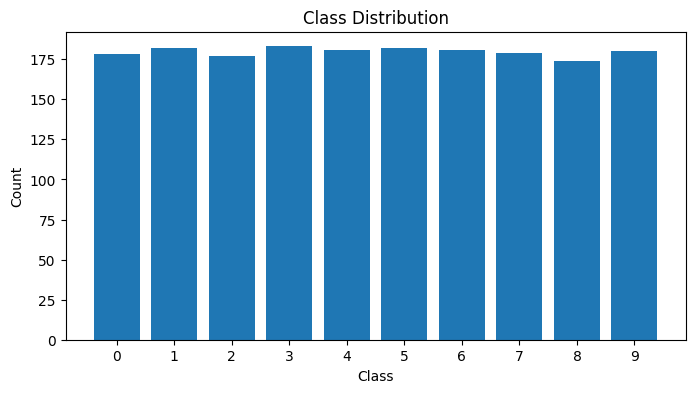

In [9]:

plt.figure(figsize=(8, 4))
plt.bar(class_df["class"], class_df["count"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks(range(10))
plt.show()

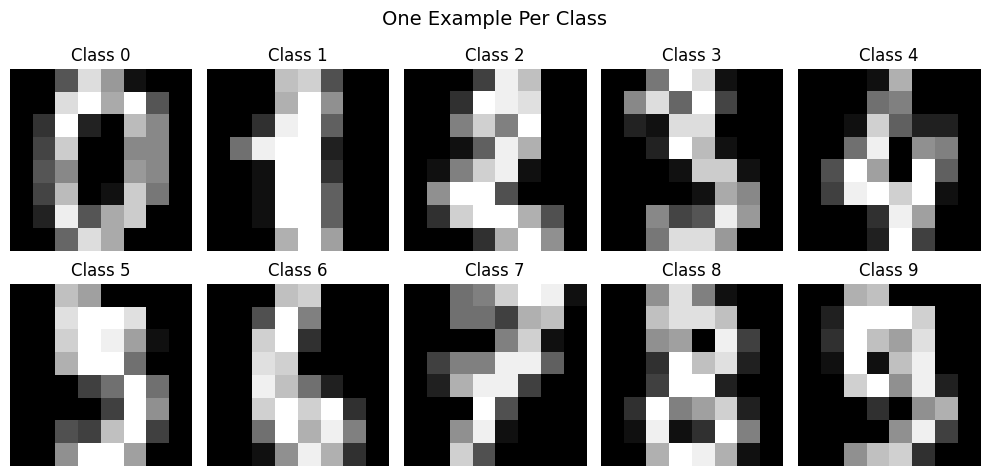

In [10]:
# Chunk 6: Show one example per class
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for cls in range(10):
    idx = np.where(y == cls)[0][0]
    axes[cls].imshow(X[idx], cmap="gray")
    axes[cls].set_title(f"Class {cls}")
    axes[cls].axis("off")

plt.suptitle("One Example Per Class", fontsize=14)
plt.tight_layout()
plt.show()

## Task 1

I selected the scikit learn digits dataset. It contains grayscale images of handwritten digits and is appropriate for CNN modelling because each sample is an image with meaningful local spatial patterns such as edges, curves, and strokes. The input shape is 8 × 8 × 1, and there are 10 classes** representing digits 0 to 9.

One training example represents a single handwritten digit image and its class label. Spatial structure matters because nearby pixels combine to form meaningful shapes such as loops, corners, and vertical or horizontal strokes. A fully connected network would treat each pixel independently at the first layer, which ignores locality and uses more parameters than necessary. A CNN is more efficient because convolution reuses the same small filter across the image to detect local patterns.

In [11]:
# Chunk 7: Train / validation / test split
# First split off test set, then split training into train/validation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, stratify=y_temp, random_state=SEED
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1149, 8, 8)
Validation shape: (288, 8, 8)
Test shape: (360, 8, 8)


In [12]:
X_train = X_train / 16.0
X_val   = X_val / 16.0
X_test  = X_test / 16.0



X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

print("Tensor train shape:", X_train_tensor.shape)

Tensor train shape: torch.Size([1149, 1, 8, 8])


In [13]:

batch_size = 32

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False
)

In [15]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(8 * 4 * 4, 10)

    def forward(self, x):
        x = self.conv(x)
        x = torch.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

baseline_model = BaselineCNN().to(device)
print(baseline_model)

BaselineCNN(
  (conv): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


## Task 2

The baseline CNN contains:

one convolutional layer,

one pooling layer,

one fully connected output layer.

Conceptually, the convolution layer learns small visual patterns such as edges, strokes, and simple textures by sliding filters across the image. Pooling reduces the spatial size of the feature maps, which lowers computation and helps the model focus on whether a feature exists rather than its exact location. The baseline model has the number of trainable parameters reported in the code output above.

Task 3
I extended the baseline model by adding:

a second convolutional layer,

dropout after pooling.

I expect the extra convolution layer to help because it can combine simple low-level features from the first layer into more complex patterns, such as digit parts and stroke combinations. I added dropout to reduce the risk of memorising the training data. One possible risk is that the more complex architecture may overfit or become less stable if the dataset is small.

In [16]:
class ExtendedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.25)
        self.fc = nn.Linear(16 * 4 * 4, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

extended_model = ExtendedCNN().to(device)
print(extended_model)

ExtendedCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=256, out_features=10, bias=True)
)


In [17]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Baseline trainable parameters:", count_parameters(baseline_model))
print("Extended trainable parameters:", count_parameters(extended_model))

Baseline trainable parameters: 1370
Extended trainable parameters: 3818


In [18]:
def evaluate_model(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc


def train_model(model, train_loader, val_loader, epochs=20, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    return history

In [19]:
baseline_model = BaselineCNN().to(device)
baseline_history = train_model(
    baseline_model,
    train_loader,
    val_loader,
    epochs=20,
    lr=0.001
)

Epoch 01/20 | Train Loss: 2.2414 | Train Acc: 0.2602 | Val Loss: 2.1472 | Val Acc: 0.4688
Epoch 02/20 | Train Loss: 2.0635 | Train Acc: 0.5849 | Val Loss: 1.9374 | Val Acc: 0.7743
Epoch 03/20 | Train Loss: 1.8265 | Train Acc: 0.7337 | Val Loss: 1.6617 | Val Acc: 0.8438
Epoch 04/20 | Train Loss: 1.5341 | Train Acc: 0.8251 | Val Loss: 1.3647 | Val Acc: 0.8507
Epoch 05/20 | Train Loss: 1.2474 | Train Acc: 0.8486 | Val Loss: 1.0897 | Val Acc: 0.8438
Epoch 06/20 | Train Loss: 0.9993 | Train Acc: 0.8503 | Val Loss: 0.8660 | Val Acc: 0.8993
Epoch 07/20 | Train Loss: 0.8093 | Train Acc: 0.8729 | Val Loss: 0.7125 | Val Acc: 0.9167
Epoch 08/20 | Train Loss: 0.6751 | Train Acc: 0.8851 | Val Loss: 0.5874 | Val Acc: 0.9271
Epoch 09/20 | Train Loss: 0.5770 | Train Acc: 0.8947 | Val Loss: 0.5102 | Val Acc: 0.9236
Epoch 10/20 | Train Loss: 0.5047 | Train Acc: 0.9034 | Val Loss: 0.4445 | Val Acc: 0.9340
Epoch 11/20 | Train Loss: 0.4480 | Train Acc: 0.9095 | Val Loss: 0.3951 | Val Acc: 0.9444
Epoch 12/2

In [20]:
extended_model = ExtendedCNN().to(device)
extended_history = train_model(
    extended_model,
    train_loader,
    val_loader,
    epochs=20,
    lr=0.001
)

Epoch 01/20 | Train Loss: 2.2423 | Train Acc: 0.2359 | Val Loss: 2.1219 | Val Acc: 0.8333
Epoch 02/20 | Train Loss: 1.9169 | Train Acc: 0.6414 | Val Loss: 1.5493 | Val Acc: 0.8472
Epoch 03/20 | Train Loss: 1.2217 | Train Acc: 0.7720 | Val Loss: 0.7437 | Val Acc: 0.8819
Epoch 04/20 | Train Loss: 0.6554 | Train Acc: 0.8512 | Val Loss: 0.4073 | Val Acc: 0.9167
Epoch 05/20 | Train Loss: 0.4377 | Train Acc: 0.8799 | Val Loss: 0.2834 | Val Acc: 0.9479
Epoch 06/20 | Train Loss: 0.3441 | Train Acc: 0.8982 | Val Loss: 0.2377 | Val Acc: 0.9271
Epoch 07/20 | Train Loss: 0.3125 | Train Acc: 0.9051 | Val Loss: 0.2021 | Val Acc: 0.9444
Epoch 08/20 | Train Loss: 0.2907 | Train Acc: 0.9060 | Val Loss: 0.1718 | Val Acc: 0.9583
Epoch 09/20 | Train Loss: 0.2498 | Train Acc: 0.9225 | Val Loss: 0.1598 | Val Acc: 0.9549
Epoch 10/20 | Train Loss: 0.2120 | Train Acc: 0.9382 | Val Loss: 0.1392 | Val Acc: 0.9722
Epoch 11/20 | Train Loss: 0.2016 | Train Acc: 0.9399 | Val Loss: 0.1265 | Val Acc: 0.9722
Epoch 12/2

## Task 4

## Baseline CNN
Comment on:

whether training and validation loss both decrease,

whether validation accuracy improves steadily,

whether there is a widening gap between train and validation performance,

whether learning appears smooth or noisy.

## Extended CNN
Comment on:

whether the model converges faster or slower than the baseline,

whether the validation metrics are more stable,

whether added complexity improves representation learning,

whether the extra capacity introduces signs of overfitting.

Overall, relate convergence and stability to architectural complexity rather than only reporting final accuracy.

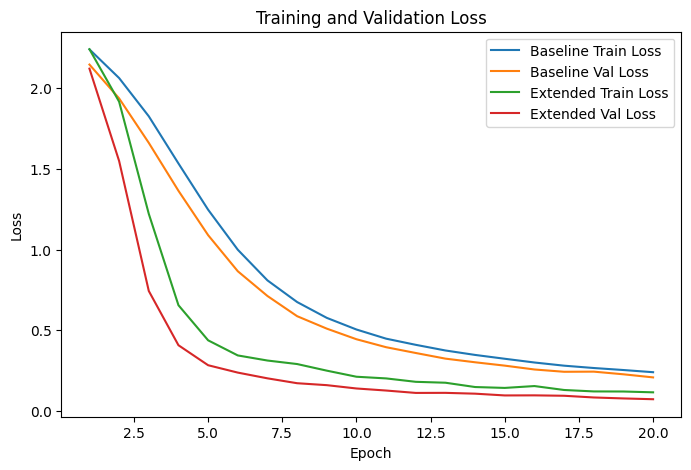

In [21]:
epochs_range = range(1, len(baseline_history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, baseline_history["train_loss"], label="Baseline Train Loss")
plt.plot(epochs_range, baseline_history["val_loss"], label="Baseline Val Loss")
plt.plot(epochs_range, extended_history["train_loss"], label="Extended Train Loss")
plt.plot(epochs_range, extended_history["val_loss"], label="Extended Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

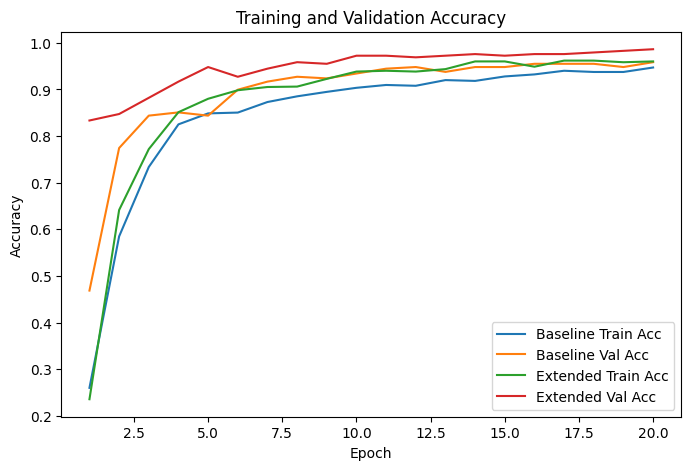

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, baseline_history["train_acc"], label="Baseline Train Acc")
plt.plot(epochs_range, baseline_history["val_acc"], label="Baseline Val Acc")
plt.plot(epochs_range, extended_history["train_acc"], label="Extended Train Acc")
plt.plot(epochs_range, extended_history["val_acc"], label="Extended Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [23]:
criterion = nn.CrossEntropyLoss()

baseline_test_loss, baseline_test_acc = evaluate_model(baseline_model, test_loader, criterion)
extended_test_loss, extended_test_acc = evaluate_model(extended_model, test_loader, criterion)

print(f"Baseline Test Loss: {baseline_test_loss:.4f}")
print(f"Baseline Test Accuracy: {baseline_test_acc:.4f}")

print(f"Extended Test Loss: {extended_test_loss:.4f}")
print(f"Extended Test Accuracy: {extended_test_acc:.4f}")

Baseline Test Loss: 0.2515
Baseline Test Accuracy: 0.9389
Extended Test Loss: 0.0935
Extended Test Accuracy: 0.9778


In [24]:
summary_df = pd.DataFrame({
    "Model": ["Baseline CNN", "Extended CNN"],
    "Trainable Parameters": [
        count_parameters(baseline_model),
        count_parameters(extended_model)
    ],
    "Final Train Accuracy": [
        baseline_history["train_acc"][-1],
        extended_history["train_acc"][-1]
    ],
    "Final Validation Accuracy": [
        baseline_history["val_acc"][-1],
        extended_history["val_acc"][-1]
    ],
    "Test Accuracy": [
        baseline_test_acc,
        extended_test_acc
    ]
})

display(summary_df)

,Model,Trainable Parameters,Final Train Accuracy,Final Validation Accuracy,Test Accuracy
0,Baseline CNN,1370,0.946910,0.958333,0.938889
1,Extended CNN,3818,0.959965,0.986111,0.977778


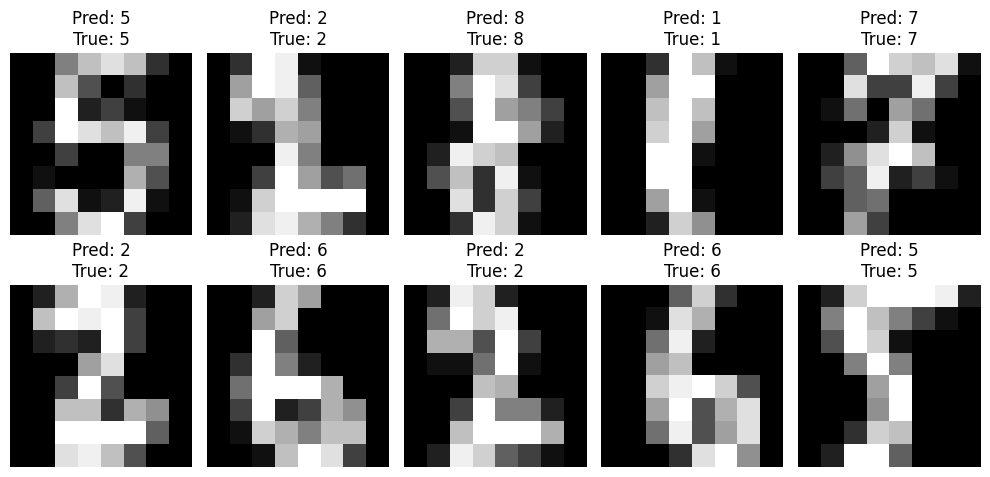

In [25]:
extended_model.eval()

xb, yb = next(iter(test_loader))
xb = xb.to(device)

with torch.no_grad():
    outputs = extended_model(xb)
    preds = outputs.argmax(dim=1).cpu().numpy()

images = xb.cpu().numpy().squeeze(1)
true_labels = yb.numpy()

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(images[i], cmap="gray")
    axes[i].set_title(f"Pred: {preds[i]}\nTrue: {true_labels[i]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Task 5

The test set must not guide architecture design because it is meant to estimate how well the final chosen model generalises to unseen data. If architecture choices are repeatedly adjusted based on test performance, the test set stops being an unbiased evaluation set. In this notebook, model choices were made using the training and validation sets only, and the test set was used once at the end.

Compare the final test results with the validation trends and state whether they broadly agree. Avoid over-interpreting small numerical differences.